In [1]:
# !pip install torch
# !pip install torchvision


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchsummary import summary

# Hyperparameters
device = "cuda" if torch.cuda.is_available() else "cpu"
# Check if CUDA (GPU support) is available
if device == "cuda":
    # Get the number of available GPUs
    gpu_count = torch.cuda.device_count()
    print(f"CUDA is available. Using {gpu_count} GPU(s).")
    
    # Print the name of each GPU
    for i in range(gpu_count):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("CUDA not available. Using CPU.")

# --- End of recommended block ---


lr =0.0002  # Learning rate
batch_size = 128
image_size = 64
channels_img = 1 # MNIST is grayscale
z_dim = 100 # Latent dimension (noise)
num_epochs = 50 # As required by the assignment

transform_pipeline = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5 for _ in range(channels_img)], [0.5 for _ in range(channels_img)]),
])

dataset = datasets.MNIST(root="dataset/", train=True, transform=transform_pipeline, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,num_workers=4 )

CUDA is available. Using 1 GPU(s).
  GPU 0: NVIDIA GeForce RTX 5060


In [2]:
class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            nn.ConvTranspose2d(z_dim, features_g * 16, 4, 1, 0, bias=False), # N x f_g*16 x 4 x 4
            nn.BatchNorm2d(features_g * 16),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 16, features_g * 8, 4, 2, 1, bias=False), # N x f_g*8 x 8 x 8
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False), # N x f_g*4 x 16 x 16
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False), # N x f_g*2 x 32 x 32
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 2, channels_img, 4, 2, 1, bias=False), # N x channels_img x 64 x 64
            nn.Tanh() # Output: [-1, 1]
        )

    def forward(self, x):
        return self.net(x)

In [3]:
class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            # Input: N x channels_img x 64 x 64
            nn.Conv2d(channels_img, features_d, 4, 2, 1, bias=False), # N x f_d x 32 x 32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False), # N x f_d*2 x 16 x 16
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False), # N x f_d*4 x 8 x 8
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1, bias=False), # N x f_d*8 x 4 x 4
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 8, 1, 4, 2, 0, bias=False), # N x 1 x 1 x 1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [4]:
# Initialize models
gen = Generator(z_dim, channels_img, 64).to(device)
disc = Discriminator(channels_img, 64).to(device)

# Optimizers
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

# Loss function
criterion = nn.BCELoss()

In [5]:
# --- Print Generator Summary ---
# Input shape for the Generator is the noise vector
print("------------------------------------------------------------")
print("                 GAN   Generator Summary")
print("------------------------------------------------------------")
summary(gen, (z_dim, 1, 1))

------------------------------------------------------------
                 GAN   Generator Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 64, 64]           --
|    └─ConvTranspose2d: 2-1              [-1, 1024, 4, 4]          1,638,400
|    └─BatchNorm2d: 2-2                  [-1, 1024, 4, 4]          2,048
|    └─ReLU: 2-3                         [-1, 1024, 4, 4]          --
|    └─ConvTranspose2d: 2-4              [-1, 512, 8, 8]           8,388,608
|    └─BatchNorm2d: 2-5                  [-1, 512, 8, 8]           1,024
|    └─ReLU: 2-6                         [-1, 512, 8, 8]           --
|    └─ConvTranspose2d: 2-7              [-1, 256, 16, 16]         2,097,152
|    └─BatchNorm2d: 2-8                  [-1, 256, 16, 16]         512
|    └─ReLU: 2-9                         [-1, 256, 16, 16]         --
|    └─ConvTranspose2d: 2-10      

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 64, 64]           --
|    └─ConvTranspose2d: 2-1              [-1, 1024, 4, 4]          1,638,400
|    └─BatchNorm2d: 2-2                  [-1, 1024, 4, 4]          2,048
|    └─ReLU: 2-3                         [-1, 1024, 4, 4]          --
|    └─ConvTranspose2d: 2-4              [-1, 512, 8, 8]           8,388,608
|    └─BatchNorm2d: 2-5                  [-1, 512, 8, 8]           1,024
|    └─ReLU: 2-6                         [-1, 512, 8, 8]           --
|    └─ConvTranspose2d: 2-7              [-1, 256, 16, 16]         2,097,152
|    └─BatchNorm2d: 2-8                  [-1, 256, 16, 16]         512
|    └─ReLU: 2-9                         [-1, 256, 16, 16]         --
|    └─ConvTranspose2d: 2-10             [-1, 128, 32, 32]         524,288
|    └─BatchNorm2d: 2-11                 [-1, 128, 32, 32]         256
|    └─ReLU: 2-12                        [-1, 128, 

In [6]:
# --- Print Discriminator Summary ---
# Input shape for the Discriminator is the image
print("\n\n------------------------------------------------------------")
print("                 GAN  Discriminator Summary")
print("------------------------------------------------------------")
summary(disc, (channels_img, image_size, image_size))



------------------------------------------------------------
                 GAN  Discriminator Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 1, 1]             --
|    └─Conv2d: 2-1                       [-1, 64, 32, 32]          1,024
|    └─LeakyReLU: 2-2                    [-1, 64, 32, 32]          --
|    └─Conv2d: 2-3                       [-1, 128, 16, 16]         131,072
|    └─BatchNorm2d: 2-4                  [-1, 128, 16, 16]         256
|    └─LeakyReLU: 2-5                    [-1, 128, 16, 16]         --
|    └─Conv2d: 2-6                       [-1, 256, 8, 8]           524,288
|    └─BatchNorm2d: 2-7                  [-1, 256, 8, 8]           512
|    └─LeakyReLU: 2-8                    [-1, 256, 8, 8]           --
|    └─Conv2d: 2-9                       [-1, 512, 4, 4]           2,097,152
|    └─BatchNorm2d: 2-10           

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 1, 1]             --
|    └─Conv2d: 2-1                       [-1, 64, 32, 32]          1,024
|    └─LeakyReLU: 2-2                    [-1, 64, 32, 32]          --
|    └─Conv2d: 2-3                       [-1, 128, 16, 16]         131,072
|    └─BatchNorm2d: 2-4                  [-1, 128, 16, 16]         256
|    └─LeakyReLU: 2-5                    [-1, 128, 16, 16]         --
|    └─Conv2d: 2-6                       [-1, 256, 8, 8]           524,288
|    └─BatchNorm2d: 2-7                  [-1, 256, 8, 8]           512
|    └─LeakyReLU: 2-8                    [-1, 256, 8, 8]           --
|    └─Conv2d: 2-9                       [-1, 512, 4, 4]           2,097,152
|    └─BatchNorm2d: 2-10                 [-1, 512, 4, 4]           1,024
|    └─LeakyReLU: 2-11                   [-1, 512, 4, 4]           --
|    └─Conv2d: 2-12                      [-1, 1, 1, 1]      

In [7]:
# Create a fixed noise vector to see the progression of the generator
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device) # We'll generate a grid of 8x8=64 images

In [8]:
# Before the training loop starts
G_losses = []
D_losses = []

In [9]:
import csv
import os
from torchvision.utils import save_image

# --- Setup CSV logging ---
loss_file_path = "gan.csv"
with open(loss_file_path, 'w', newline='') as f:
    writer = csv.writer(f)
    # Write the header for the CSV file
    writer.writerow(["Epoch", "Discriminator_Loss", "Generator_Loss"])

# Make sure you have a folder named 'gan_samples' or change the path
os.makedirs("gan_samples", exist_ok=True)
print("Starting GAN Training...")
# Main training loop
for epoch in range(num_epochs):
    for batch_idx, (real, _) in enumerate(loader):
        real = real.to(device)
        batch_size = real.shape[0]

        ### Train Discriminator ###
        disc.zero_grad()
        # Real images
        label_real = torch.ones(batch_size, 1, 1, 1).to(device)
        output_real = disc(real)
        loss_disc_real = criterion(output_real, label_real)

        # Fake images
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)
        label_fake = torch.zeros(batch_size, 1, 1, 1).to(device)
        output_fake = disc(fake.detach())
        loss_disc_fake = criterion(output_fake, label_fake)

        loss_disc = loss_disc_real + loss_disc_fake
        loss_disc.backward()
        opt_disc.step()

        ### Train Generator ###
        gen.zero_grad()
        output_gen = disc(fake)
        loss_gen = criterion(output_gen, label_real)
        loss_gen.backward()
        opt_gen.step()

    # --- End of Epoch ---
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}") 
    # Append losses for this epoch to the CSV file
    with open(loss_file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, loss_disc.item(), loss_gen.item()])

    # Save sample images
    with torch.no_grad():
        fake_samples = gen(fixed_noise)
        save_image(fake_samples, f"gan_samples/sample_epoch_{epoch+1}.png", normalize=True)

print("Training Complete. Loss data saved to gan.csv")

Starting GAN Training...
Epoch [1/50] Loss D: 0.0030, Loss G: 6.7921
Epoch [2/50] Loss D: 0.0623, Loss G: 8.9089
Epoch [3/50] Loss D: 0.6113, Loss G: 1.6205
Epoch [4/50] Loss D: 1.1827, Loss G: 0.9447
Epoch [5/50] Loss D: 0.1624, Loss G: 3.7697
Epoch [6/50] Loss D: 1.1087, Loss G: 4.5494
Epoch [7/50] Loss D: 0.0977, Loss G: 4.0387
Epoch [8/50] Loss D: 0.2609, Loss G: 3.5193
Epoch [9/50] Loss D: 0.6526, Loss G: 2.0130
Epoch [10/50] Loss D: 0.2519, Loss G: 3.5823
Epoch [11/50] Loss D: 0.0343, Loss G: 5.2452
Epoch [12/50] Loss D: 0.4567, Loss G: 3.9839
Epoch [13/50] Loss D: 0.5442, Loss G: 2.0675
Epoch [14/50] Loss D: 6.6498, Loss G: 2.0007
Epoch [15/50] Loss D: 0.9203, Loss G: 4.2817
Epoch [16/50] Loss D: 0.3990, Loss G: 2.0703
Epoch [17/50] Loss D: 0.0405, Loss G: 4.5925
Epoch [18/50] Loss D: 0.0396, Loss G: 4.2976
Epoch [19/50] Loss D: 0.6337, Loss G: 3.5497
Epoch [20/50] Loss D: 0.1159, Loss G: 3.1215
Epoch [21/50] Loss D: 0.3880, Loss G: 2.7766
Epoch [22/50] Loss D: 0.0109, Loss G: 7

In [11]:
# !pip install matplotlib


Attempting to plot from gan.csv...
Plot saved successfully to gan_loss_plot.png


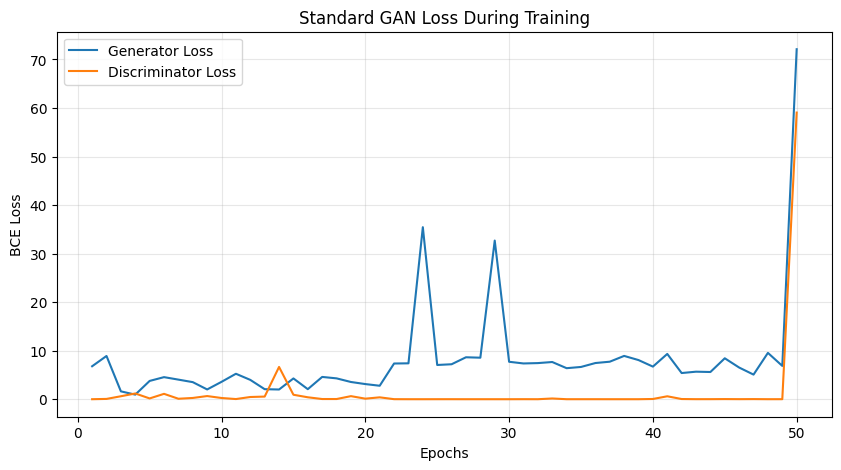

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Define file paths
loss_file = "gan.csv"
output_plot = "gan_loss_plot.png"

print(f"Attempting to plot from {loss_file}...")

try:
    # Read the data from the CSV file
    df = pd.read_csv(loss_file)

    # Create the plot
    plt.figure(figsize=(10, 5))
    plt.plot(df["Epoch"], df["Generator_Loss"], label="Generator Loss")
    plt.plot(df["Epoch"], df["Discriminator_Loss"], label="Discriminator Loss")
    
    plt.title("Standard GAN Loss During Training")
    plt.xlabel("Epochs")
    plt.ylabel("BCE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    # Save the plot
    plt.savefig(output_plot)
    print(f"Plot saved successfully to {output_plot}")
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{loss_file}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

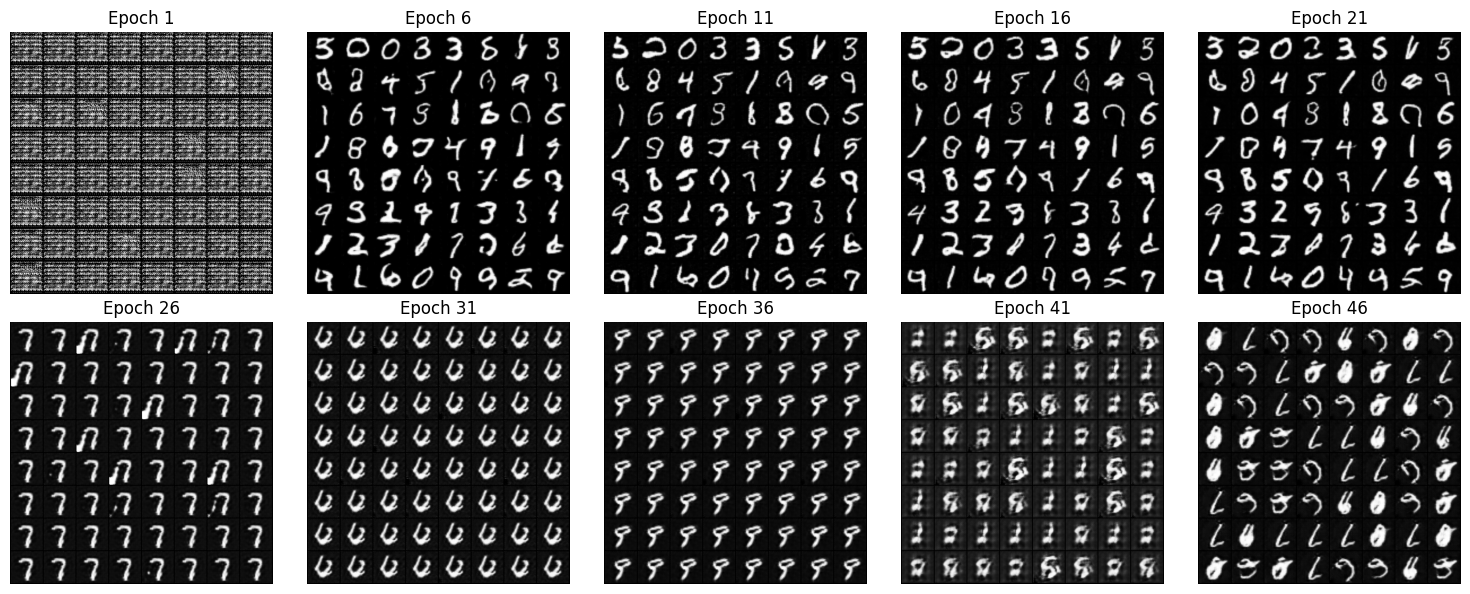

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = "gan_samples"
epochs = 50
step = 5

# Collect epochs to display
selected_epochs = list(range(1, epochs+1, step))

# Calculate grid size
cols = 5  # number of images per row
rows = (len(selected_epochs) + cols - 1) // cols

# Prepare the figure
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))

for idx, epoch in enumerate(selected_epochs):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c] if rows > 1 else axes[c]

    img_path = os.path.join(folder, f"sample_epoch_{epoch}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"Epoch {epoch}")
    ax.axis('off')

# Turn off any empty subplots
for i in range(len(selected_epochs), rows*cols):
    r = i // cols
    c = i % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.axis('off')
plt.tight_layout()
plt.show()